In [1]:
import pandas as pd

### `Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [35]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [45]:
# name index levels so stack/unstack knows what to move
df.index.names = ["branch", "year"]

# swap branch <-> city between index and columns
result = df.stack(level=0).unstack(level=0)

# fix column order: branch, city
result = result.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

# fix index order: city, year
result = result.swaplevel(0, 1, axis=0).sort_index(axis=0, level=0)

result

branch              cse                  ece         
            avg_package students avg_package students
       year                                          
delhi  2019           1        2           9       10
       2020           3        4          11       12
       2021           5        6          13       14
       2022           7        8          15       16
mumbai 2019           0        0           0        0
       2020           0        0           0        0
       2021           0        0           0        0
       2022           0        0           0        0

### `Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [46]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [61]:
deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [65]:
# melt date columns into rows for both datasets
confirm_long = confirm.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Cases"
)

deaths_long = deaths.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Deaths"
)

# merge confirmed cases and deaths on country, province, date
covid_df = confirm_long.merge(
    deaths_long[["Province/State", "Country/Region", "Date", "Deaths"]],
    on=["Province/State", "Country/Region", "Date"]
)

covid_df = covid_df[["Country/Region", "Province/State", "Date", "Cases", "Deaths"]]

# set Country as level-0 index, Province/State as level-1 index
covid_df = covid_df.set_index(["Country/Region", "Province/State"])

covid_df

,,Date,Cases,Deaths
Country/Region,Province/State,,,
Afghanistan,nan,1/22/20,0,0
Albania,nan,1/22/20,0,0
Algeria,nan,1/22/20,0,0
Andorra,nan,1/22/20,0,0
Angola,nan,1/22/20,0,0
...,...,...,...,...
West Bank and Gaza,nan,1/2/23,703228,5708
Winter Olympics 2022,nan,1/2/23,535,0
Yemen,nan,1/2/23,11945,2159


### `Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [163]:
df = covid_df.reset_index()

# take latest date only

latest = df[df["Date"] == df["Date"].max()]

# total cases and deaths per country
country_totals = latest.groupby("Country/Region")[["Cases", "Deaths"]].sum()

# death percent
country_totals["Death %"] = country_totals["Deaths"] / country_totals["Cases"] * 100

print(country_totals["Death %"].idxmax())

Korea, North


### `Q-4` : Make a dataframe for Pakistan from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [103]:
pakistan_df = covid_df.reset_index()
pakistan_df = pakistan_df[pakistan_df["Country/Region"] == "Pakistan"]

# sort by date so shift works correctly
pakistan_df["Date"] = pd.to_datetime(pakistan_df["Date"])
pakistan_df = pakistan_df.sort_values("Date")

# new cases = today's cases - previous day's cases
pakistan_df["NewCases"] = pakistan_df["Cases"] - pakistan_df["Cases"].shift(1)

pakistan_df

C:\Users\Dell\AppData\Local\Temp\ipykernel_3132\1334883224.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pakistan_df["Date"] = pd.to_datetime(pakistan_df["Date"])


,Country/Region,Province/State,Date,Cases,Deaths,NewCases
210,Pakistan,NaN,2020-01-22,0,0,NaN
499,Pakistan,NaN,2020-01-23,0,0,0.0
788,Pakistan,NaN,2020-01-24,0,0,0.0
1077,Pakistan,NaN,2020-01-25,0,0,0.0
1366,Pakistan,NaN,2020-01-26,0,0,0.0
...,...,...,...,...,...,...
310018,Pakistan,NaN,2022-12-29,1575772,30636,121.0
310307,Pakistan,NaN,2022-12-30,1575772,30636,0.0
310596,Pakistan,NaN,2022-12-31,1575772,30636,0.0
310885,Pakistan,NaN,2023-01-01,1575817,30636,45.0


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of Pakistan which is most poluted based on PM10.
2. Find out the name of the city of Pakistan which has minimum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [152]:
import matplotlib.pyplot as plt

Most polluted (Pakistan): Peshawar
Least polluted (Pakistan): Faisalabad
Most polluted (China): Jinan
Least polluted (China): Anshun


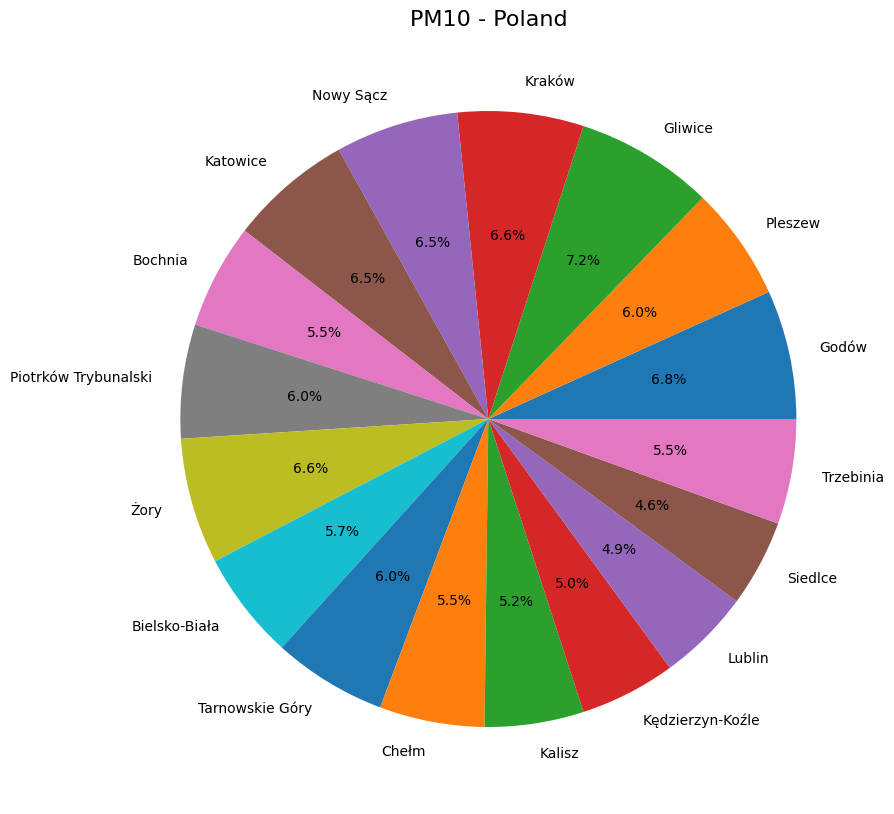

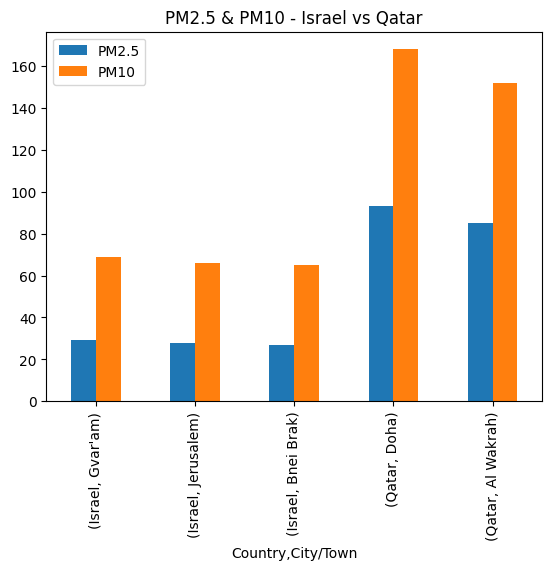

Country  City/Town                         
India    Kanpur     Unnamed: 0                    0
                    Position                      1
                    Year                       2016
                    PM2.5                       173
                    Temporal coverage          >75%
                                               ... 
Turkey   Sivas      PM2.5                        27
                    Temporal coverage          >75%
                    PM10                         56
                    Temporal coverage.1        >75%
                    Database version (year)    2018
Length: 4000, dtype: object


In [160]:
pollution_df = pd.read_csv("https://tinyurl.com/2fe6vz4u")
pollution_df.head()

# set multi-index
pollution_df = pollution_df.set_index(["Country", "City/Town"])
pollution_df

# 1. most polluted city in Pakistan (PM10)
pakistan_pm10 = pollution_df.loc["Pakistan"]["PM10"]
print("Most polluted (Pakistan):", pakistan_pm10.idxmax())

# 2. least polluted city in Pakistan (PM10)
print("Least polluted (Pakistan):", pakistan_pm10.idxmin())

# 3. same for China
china_pm10 = pollution_df.loc["China"]["PM10"]
print("Most polluted (China):", china_pm10.idxmax())
print("Least polluted (China):", china_pm10.idxmin())

# 4. pie chart - Poland PM10
plt.figure(figsize=(10,10))   # Width, Height

poland_pm10 = pollution_df.loc["Poland"]["PM10"]
poland_pm10.plot.pie(
    autopct="%1.1f%%"
)

plt.title("PM10 - Poland", fontsize=16)
plt.ylabel("")   
plt.show()


# 5. bar chart - Israel & Qatar, PM2.5 and PM10
subset = pollution_df.loc[["Israel", "Qatar"]][["PM2.5", "PM10"]]
subset.plot.bar()
plt.title("PM2.5 & PM10 - Israel vs Qatar")
plt.show()

# 6. MultiIndex DataFrame -> Series (stack columns into index)
pollution_series = pollution_df.stack()
print(pollution_series)
